In [1]:
import pandas as pd
import torch
import numpy as np
import os
from Bio import SeqIO
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

enzyme_df= pd.read_csv('../../data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

msa_df = enzyme_df.copy()

In [2]:
msa_dir = "../../data/msa_files/msa"

def calculate_entropy(sequences):
    # print(sequences.shape)
    num_seq, alignment_length = sequences.shape
    entropies = []

    for i in np.arange(alignment_length):
        column = sequences[:, i]
        if np.sum(column == '-') / num_seq >= 0.3:
            entropies.append(100)
            continue
            
        column = column[column != '-']   
        values, counts = np.unique(column, return_counts=True)
        p = counts / num_seq
        entropy = -np.sum(p * np.log(p))
        entropies.append(entropy)

    return entropies

msa_df['MSAEntropies'] = None
msa_df['AlignedSequence'] = None
msa_df['NumAligned'] = None
max_len = 0

for msa_file in os.listdir(msa_dir):
    if not msa_file.endswith(".fasta"):
        continue  # Skip files that are not FASTA
    # filter the msa data for only the proteins in the enzyme dataset because the msa dataset has more
    # print(msa_file)
    uniprot_id = msa_file.split('enzyme_')[1].split('_aligned.fasta')[0]
    if msa_file.endswith(".fasta") and uniprot_id in msa_df[["UniprotID"]].values:
        msa_path = os.path.join(msa_dir, msa_file)
        sequences = list(SeqIO.parse(msa_path, "fasta"))
        num_sequences = len(sequences)
        sequences_array = np.array([list(str(record.seq)) for record in sequences])
        entropies = calculate_entropy(sequences_array)
        
        aligned_sequence = None
        for record in sequences:
            if uniprot_id in record.id:
                aligned_sequence = str(record.seq)
                break
        
        if aligned_sequence is not None:
            index = msa_df[msa_df['UniprotID'] == uniprot_id].index[0]
            msa_df.at[index, 'MSAEntropies'] = entropies
            msa_df.at[index, 'AlignedSequence'] = aligned_sequence
            msa_df.at[index, 'NumAligned'] = num_sequences
        
        max_len = max(max_len, len(entropies))

In [3]:
msa_df

,UniprotID,AnnotatedIndices,EnzymeClass,GOTerm,Sequence,GOTermIndex,MSAEntropies,AlignedSequence,NumAligned
1,A0QTN8,"[162, 191, 217, 242, 266, 294]",5.5.1.1,GO:0018849,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...,12611,"[0.02352380035098766, 100, 100, 100, 100, 100,...",M-------------------------KIVAIGAIPF-SIPYT-K-P...,42
2,A2RJT9,"[43, 130]",1.3.98.1,GO:1990663,MLNTTFANAKFANPFMNASGVHCMTIEDLEELKASQAGAYITKSST...,6256,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",----------------M-----------------------------...,124
3,A4XF23,"[147, 159, 210, 212, 236, 262, 283, 339]",4.2.1.8,GO:0008927,MKITAARVIITCPGRNFVTLKIETDQGVYGIGDATLNGRELSVVAY...,1500,"[100, 100, 100, 100, 0.13212915413765, 100, 10...",----------------------------------------------...,70
4,A5JTM5,"[64, 86, 90, 114, 137, 145]",3.8.1.7,GO:0018787,MYEAIGHRVEDGVAEITIKLPRHRNALSVKAMQEVTDALNRAEEDD...,19157,"[0.012421547429274322, 2.14418965615015, 2.541...",MYE-A-----------------------------------------...,80
5,A5JUY8,"[105, 108, 110, 184, 186, 188, 190, 258, 351]",1.11.1.7,GO:0140825,MWVCLQLPVFLASVTLFEVAASDTIAQAASTTTISDAVSKVKIQVN...,2030,"[0.05931080560388677, 2.2511896196699985, 2.42...",MWV--------------------------C----------------...,49
...,...,...,...,...,...,...,...,...,...
842,Q9YHT1,"[130, 251, 253, 263, 266, 297, 364, 408]",1.3.5.1,GO:0008177,MAAVVAASRSLAKCWLRPAVRAWPAACQTHARNFHFTVDGKKNAST...,3811,"[100, 100, 100, 100, 0.07664880077618422, 2.36...",----MAAV---VA-ASR-----------------------------...,68
843,Q9ZAG3,"[53, 55, 99, 101, 132]",3.3.2.8,GO:0018744,MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...,26152,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...,1
844,Q9ZF13,"[50, 127, 128, 196, 198, 225, 254]",3.2.1.78,GO:0016985,GLHVKNGRLYEANGQEFIIRGVSHPHNWYPQHTQAFADIKSHGANT...,4352,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",----------------------------------------------...,4
845,Q9ZHI0,"[114, 116, 118, 221, 312, 406, 409, 422, 427]",6.5.1.2,GO:0003911,MTREEARRRINELRDLIRYHNYRYYVLADPEISDAEYDRLLRELKE...,389,"[0.009680158934752813, 100, 100, 100, 100, 100...",M-------------------T---------------------R---...,514


In [4]:
print(max_len)

46275


In [5]:
sum(msa_df["AlignedSequence"].isna())

13

In [6]:
def update_annotated_indices(original_seq, aligned_seq, original_indices):
    original_idx = 0
    aligned_idx = 0
    index_mapping = {}

    while aligned_idx < len(aligned_seq):
        if aligned_seq[aligned_idx] != '-':
            if original_idx in original_indices:
                index_mapping[original_idx] = aligned_idx
            original_idx += 1
        aligned_idx += 1

    new_indices = [index_mapping[idx] for idx in original_indices]
    return new_indices

In [7]:
import torch

msa_df = msa_df[~msa_df['MSAEntropies'].isna()]
msa_df = msa_df[~msa_df['AlignedSequence'].isna()]

msa_df["AlignedIndices"] = None
for index, row in msa_df.iterrows():
    original_seq = row["Sequence"]
    aligned_seq = row["AlignedSequence"]
    original_indices = row["AnnotatedIndices"]
    msa_df.at[index, 'AlignedIndices'] = update_annotated_indices(original_seq, aligned_seq, original_indices)

In [8]:
msa_df

,UniprotID,AnnotatedIndices,EnzymeClass,GOTerm,Sequence,GOTermIndex,MSAEntropies,AlignedSequence,NumAligned,AlignedIndices
1,A0QTN8,"[162, 191, 217, 242, 266, 294]",5.5.1.1,GO:0018849,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...,12611,"[0.02352380035098766, 100, 100, 100, 100, 100,...",M-------------------------KIVAIGAIPF-SIPYT-K-P...,42,"[229, 270, 299, 327, 352, 381]"
2,A2RJT9,"[43, 130]",1.3.98.1,GO:1990663,MLNTTFANAKFANPFMNASGVHCMTIEDLEELKASQAGAYITKSST...,6256,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",----------------M-----------------------------...,124,"[135, 249]"
3,A4XF23,"[147, 159, 210, 212, 236, 262, 283, 339]",4.2.1.8,GO:0008927,MKITAARVIITCPGRNFVTLKIETDQGVYGIGDATLNGRELSVVAY...,1500,"[100, 100, 100, 100, 0.13212915413765, 100, 10...",----------------------------------------------...,70,"[319, 332, 393, 395, 421, 449, 470, 530]"
4,A5JTM5,"[64, 86, 90, 114, 137, 145]",3.8.1.7,GO:0018787,MYEAIGHRVEDGVAEITIKLPRHRNALSVKAMQEVTDALNRAEEDD...,19157,"[0.012421547429274322, 2.14418965615015, 2.541...",MYE-A-----------------------------------------...,80,"[472, 543, 551, 575, 602, 610]"
5,A5JUY8,"[105, 108, 110, 184, 186, 188, 190, 258, 351]",1.11.1.7,GO:0140825,MWVCLQLPVFLASVTLFEVAASDTIAQAASTTTISDAVSKVKIQVN...,2030,"[0.05931080560388677, 2.2511896196699985, 2.42...",MWV--------------------------C----------------...,49,"[914, 918, 920, 1155, 1163, 1168, 1170, 1255, ..."
...,...,...,...,...,...,...,...,...,...,...
842,Q9YHT1,"[130, 251, 253, 263, 266, 297, 364, 408]",1.3.5.1,GO:0008177,MAAVVAASRSLAKCWLRPAVRAWPAACQTHARNFHFTVDGKKNAST...,3811,"[100, 100, 100, 100, 0.07664880077618422, 2.36...",----MAAV---VA-ASR-----------------------------...,68,"[513, 694, 696, 708, 728, 761, 886, 988]"
843,Q9ZAG3,"[53, 55, 99, 101, 132]",3.3.2.8,GO:0018744,MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...,26152,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...,1,"[53, 55, 99, 101, 132]"
844,Q9ZF13,"[50, 127, 128, 196, 198, 225, 254]",3.2.1.78,GO:0016985,GLHVKNGRLYEANGQEFIIRGVSHPHNWYPQHTQAFADIKSHGANT...,4352,"[100, 100, 100, 100, 100, 100, 100, 100, 100, ...",----------------------------------------------...,4,"[106, 184, 185, 253, 255, 283, 312]"
845,Q9ZHI0,"[114, 116, 118, 221, 312, 406, 409, 422, 427]",6.5.1.2,GO:0003911,MTREEARRRINELRDLIRYHNYRYYVLADPEISDAEYDRLLRELKE...,389,"[0.009680158934752813, 100, 100, 100, 100, 100...",M-------------------T---------------------R---...,514,"[647, 649, 651, 954, 1170, 1383, 1387, 1426, 1..."


In [9]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    # token_attribution =  token_attribution # - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, max_len).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += max_len
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct

In [10]:
# at least 5 sequences 
# like the paper 
msa_df_5 = msa_df.copy()
msa_df_5 = msa_df_5[msa_df_5["NumAligned"] >= 5]
padded_values = [seq + [100] * (max_len - len(seq)) for seq in msa_df_5["MSAEntropies"].values]
msa_entropies = torch.tensor(padded_values)
mrr = mean_reciprocal_rank(-msa_entropies, msa_df_5['AlignedIndices'])
mpr = mean_percent_rank(-msa_entropies, torch.tensor([len(s) for s in msa_df_5['AlignedSequence']]), list(msa_df_5['AlignedIndices']))

print(f'5: Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')


5: Mean-Reciprocal Rank 0.0509951077401638, Mean-Percentage Rank 0.18397179245948792


In [11]:
for i in range(0, 500, 20):
    msa_df = msa_df[msa_df["NumAligned"] >= i]
    padded_values = [seq + [100] * (max_len - len(seq)) for seq in msa_df["MSAEntropies"].values]
    msa_entropies = torch.tensor(padded_values)
    mrr = mean_reciprocal_rank(-msa_entropies, msa_df['AlignedIndices'])
    mpr = mean_percent_rank(-msa_entropies, torch.tensor([len(s) for s in msa_df['AlignedSequence']]), list(msa_df['AlignedIndices']))

    print(f'{i}: Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

0: Mean-Reciprocal Rank 0.04874974116683006, Mean-Percentage Rank 0.20433710515499115
20: Mean-Reciprocal Rank 0.05558592081069946, Mean-Percentage Rank 0.16205541789531708
40: Mean-Reciprocal Rank 0.05831926688551903, Mean-Percentage Rank 0.14378023147583008
60: Mean-Reciprocal Rank 0.059666957706213, Mean-Percentage Rank 0.13393642008304596
80: Mean-Reciprocal Rank 0.06503695994615555, Mean-Percentage Rank 0.12185608595609665
100: Mean-Reciprocal Rank 0.06480316072702408, Mean-Percentage Rank 0.11638044565916061
120: Mean-Reciprocal Rank 0.06866250932216644, Mean-Percentage Rank 0.11260402202606201
140: Mean-Reciprocal Rank 0.06865818798542023, Mean-Percentage Rank 0.11530682444572449
160: Mean-Reciprocal Rank 0.06935033947229385, Mean-Percentage Rank 0.1129406988620758
180: Mean-Reciprocal Rank 0.06665948778390884, Mean-Percentage Rank 0.11279678344726562
200: Mean-Reciprocal Rank 0.06419938057661057, Mean-Percentage Rank 0.11407741159200668
220: Mean-Reciprocal Rank 0.0651930347084

Skipping P06213 due to no positive samples
Skipping P10182 due to no positive samples
Skipping P21164 due to no positive samples
Skipping P71447 due to no positive samples
Skipping P80324 due to no positive samples
Skipping Q64536 due to no positive samples
AUC at FPR 0.1: 0.026731428353550454
AUC at FPR 0.5: 0.333409665899967
AUC at FPR 1.0: 0.8211099089720961


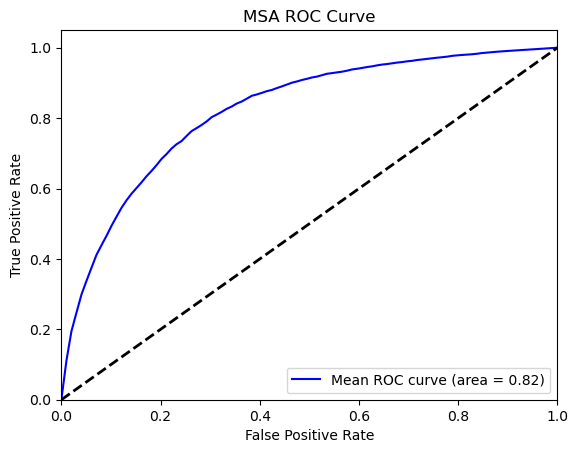

In [12]:
all_fpr = []
all_tpr = []
all_aucs = []

for index, row in msa_df_5.iterrows():
    scores = -np.array(row['MSAEntropies'])  # negative entropy as conservation score
    aligned_indices = row['AlignedIndices']
    # print(aligned_indices)
    
    labels = np.zeros(len(scores))
    labels[aligned_indices] = 1

    if np.sum(labels) == 0:
        print(f"Skipping {row['UniprotID']} due to no positive samples")
        continue

    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    all_fpr.append(fpr)
    all_tpr.append(tpr)
    all_aucs.append(roc_auc)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

auc_01 = auc(mean_fpr[mean_fpr <= 0.1], mean_tpr[mean_fpr <= 0.1])
auc_05 = auc(mean_fpr[mean_fpr <= 0.5], mean_tpr[mean_fpr <= 0.5])
auc_1 = mean_auc

print(f"AUC at FPR 0.1: {auc_01}")
print(f"AUC at FPR 0.5: {auc_05}")
print(f"AUC at FPR 1.0: {auc_1}")


plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC curve (area = {mean_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MSA ROC Curve')
plt.legend(loc="lower right")
plt.savefig("figures/MSA_AUC.png")
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
with open('/home/andrew/GO_interp/data/bert_distr.pkl', 'rb') as f:
    bert_distr = pickle.load(f)
bert_distr = torch.stack(bert_distr)
bert_attr = torch.nan_to_num((-torch.log(bert_distr)*bert_distr).sum(axis=2), 0)
bert_attr.shape

torch.Size([785, 1024])

Skipping P05725 due to no positive samples
Skipping P06213 due to no positive samples
Skipping P10182 due to no positive samples
Skipping P21164 due to no positive samples
Skipping P71447 due to no positive samples
Skipping P80324 due to no positive samples
Skipping Q64536 due to no positive samples
AUC at FPR 0.1: 0.054171931794320456
AUC at FPR 0.5: 0.4198333192781971
AUC at FPR 1.0: 0.9204922116251786


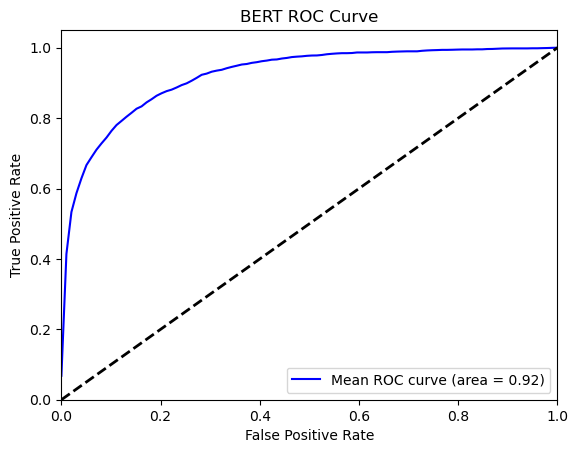

In [14]:
all_fpr = []
all_tpr = []
all_aucs = []

attribution = -bert_attr
# need to ignore padding
attribution = attribution - 1e5*(attribution == 0) #Ignore padding

for i in range(attribution.shape[0]):
    scores = attribution[i]
    annotated_indices = enzyme_df.iloc[i]["AnnotatedIndices"]
    
    labels = np.zeros(len(scores))
    labels[annotated_indices] = 1

    if np.sum(labels) == 0:
        print(f"Skipping {enzyme_df.iloc[i]['UniprotID']} due to no positive samples")
        continue

    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    all_fpr.append(fpr)
    all_tpr.append(tpr)
    all_aucs.append(roc_auc)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fpr, all_tpr)], axis=0)
mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

auc_01 = auc(mean_fpr[mean_fpr <= 0.1], mean_tpr[mean_fpr <= 0.1])
auc_05 = auc(mean_fpr[mean_fpr <= 0.5], mean_tpr[mean_fpr <= 0.5])
auc_1 = mean_auc

print(f"AUC at FPR 0.1: {auc_01}")
print(f"AUC at FPR 0.5: {auc_05}")
print(f"AUC at FPR 1.0: {auc_1}")

plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC curve (area = {mean_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERT ROC Curve')
plt.legend(loc="lower right")
plt.savefig("figures/BERT_AUC.png")
plt.show()

Skipping P06213 due to no positive samples
Skipping P10182 due to no positive samples
Skipping P21164 due to no positive samples
Skipping P71447 due to no positive samples
Skipping P80324 due to no positive samples
Skipping Q64536 due to no positive samples
Skipping P05725 due to no positive samples
Skipping P06213 due to no positive samples
Skipping P10182 due to no positive samples
Skipping P21164 due to no positive samples
Skipping P71447 due to no positive samples
Skipping P80324 due to no positive samples
Skipping Q64536 due to no positive samples


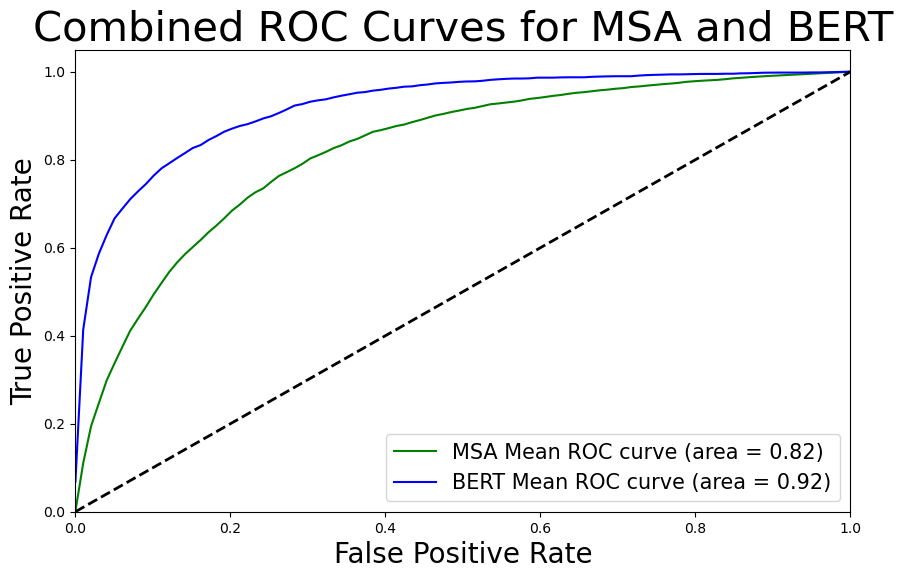

In [21]:
all_fpr_msa = []
all_tpr_msa = []
all_aucs_msa = []

for index, row in msa_df_5.iterrows():
    scores = -np.array(row['MSAEntropies'])
    aligned_indices = row['AlignedIndices']
    
    labels = np.zeros(len(scores))
    labels[aligned_indices] = 1

    if np.sum(labels) == 0:
        print(f"Skipping {row['UniprotID']} due to no positive samples")
        continue

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    all_fpr_msa.append(fpr)
    all_tpr_msa.append(tpr)
    all_aucs_msa.append(roc_auc)

mean_fpr_msa = np.linspace(0, 1, 100)
mean_tpr_msa = np.mean([np.interp(mean_fpr_msa, fpr, tpr) for fpr, tpr in zip(all_fpr_msa, all_tpr_msa)], axis=0)
mean_tpr_msa[-1] = 1.0
mean_auc_msa = auc(mean_fpr_msa, mean_tpr_msa)

all_fpr_bert = []
all_tpr_bert = []
all_aucs_bert = []

attribution = -bert_attr
attribution = attribution - 1e5 * (attribution == 0)

for i in range(attribution.shape[0]):
    scores = attribution[i]
    annotated_indices = enzyme_df.iloc[i]["AnnotatedIndices"]
    
    labels = np.zeros(len(scores))
    labels[annotated_indices] = 1

    if np.sum(labels) == 0:
        print(f"Skipping {enzyme_df.iloc[i]['UniprotID']} due to no positive samples")
        continue

    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    all_fpr_bert.append(fpr)
    all_tpr_bert.append(tpr)
    all_aucs_bert.append(roc_auc)

mean_fpr_bert = np.linspace(0, 1, 100)
mean_tpr_bert = np.mean([np.interp(mean_fpr_bert, fpr, tpr) for fpr, tpr in zip(all_fpr_bert, all_tpr_bert)], axis=0)
mean_tpr_bert[-1] = 1.0
mean_auc_bert = auc(mean_fpr_bert, mean_tpr_bert)

plt.figure(figsize=(10, 6))
plt.plot(mean_fpr_msa, mean_tpr_msa, color='g', label=f'MSA Mean ROC curve (area = {mean_auc_msa:.2f})')
plt.plot(mean_fpr_bert, mean_tpr_bert, color='b', label=f'BERT Mean ROC curve (area = {mean_auc_bert:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.title('Combined ROC Curves for MSA and BERT', fontsize=30)
plt.legend(loc="lower right", fontsize=15)
plt.savefig("figures/Combined_AUC.png")
plt.show()

In [6]:
enzyme_df = enzyme_df.reset_index(drop=True)

# different colors depending on the family size 
colors = {'small': 'y', 'medium': 'g', 'large': 'b', 'very_large': 'r'} 

for index, row in msa_df_5.iterrows():
    uniprot_id = row["UniprotID"]
    msa_entropies = -1 * np.array(row["MSAEntropies"])

    msa_indices = row["AlignedIndices"]
    
    num_aligned = row["NumAligned"]
    if (num_aligned < 20):
        color = colors['small']
    elif (num_aligned >= 20 and num_aligned < 80):
        color = colors['medium']
    elif (num_aligned >= 80 and num_aligned < 200):
        color = colors['large']
    else:
        color = colors['very_large']

    bert_row = enzyme_df[enzyme_df["UniprotID"] == uniprot_id]
    bert_row_index = bert_row.index.item()
    bert_entropies = attribution[bert_row_index]
    # you need to ignore all padding 
    seq_len = len(bert_row["Sequence"].values[0])
    bert_entropies = bert_entropies[:seq_len]
    bert_indices = bert_row['AnnotatedIndices'].values[0]

    bert_entropies_annotated = [bert_entropies[i] for i in bert_indices]
    msa_entropies_annotated = [msa_entropies[i] for i in msa_indices]

    # get rid of msa gap values 
    msa_entropies = [entropy for entropy in msa_entropies if entropy != -100]

    bert_percentiles = [percentileofscore(bert_entropies, x) for x in bert_entropies_annotated]
    msa_percentiles = [percentileofscore(msa_entropies, x) for x in msa_entropies_annotated]

    data = pd.DataFrame({
        'BERT Percentiles': bert_percentiles,
        'MSA Percentiles': msa_percentiles,
        'NumAligned': num_aligned
    })

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(data['BERT Percentiles'], data['MSA Percentiles'], c=color, alpha=0.7, edgecolors='w', s=100)
    plt.title(f'Uniprot ID: {uniprot_id}')
    plt.xlabel('BERT Percentiles')
    plt.ylabel('MSA Percentiles')
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.show()

NameError: name 'msa_df_5' is not defined